# Conditional Random Fields (CRF) for NER
This notebook trains a classical CRF model using handcrafted features.

In [1]:
import pandas as pd
import sklearn_crfsuite
from sklearn_crfsuite import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv('../nlp_d2_data/train_data_ner.csv')
test_df = pd.read_csv('../nlp_d2_data/test_data_ner.csv')

def get_sentences(df):
    agg_func = lambda s: [(w, t) for w, t in zip(s['words'].values.tolist(), s['tags'].values.tolist())]
    grouped = df.groupby('sentence_id').apply(agg_func)
    return [s for s in grouped]

train_sents = get_sentences(train_df)
test_sents = get_sentences(test_df)
print(f"Train sentences: {len(train_sents)}, Test sentences: {len(test_sents)}")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.star

AttributeError: _ARRAY_API not found

/var/folders/zk/7ccw22fx3xj60q5ntgshk6jm0000gn/T/ipykernel_57355/2616213903.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = df.groupby('sentence_id').apply(agg_func)


Train sentences: 38366, Test sentences: 38367


/var/folders/zk/7ccw22fx3xj60q5ntgshk6jm0000gn/T/ipykernel_57355/2616213903.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = df.groupby('sentence_id').apply(agg_func)


## Feature Extraction
We define features for each word in a sentence to be used by the CRF.

In [2]:
def word2features(sent, i):
    word = str(sent[i][0])
    features = {
        'bias': 1.0,
        'word.lower()': word.lower(),
        'word[-3:]': word[-3:],
        'word[-2:]': word[-2:],
        'word.isupper()': word.isupper(),
        'word.istitle()': word.istitle(),
        'word.isdigit()': word.isdigit(),
    }
    if i > 0:
        word1 = str(sent[i-1][0])
        features.update({
            '-1:word.lower()': word1.lower(),
            '-1:word.istitle()': word1.istitle(),
            '-1:word.isupper()': word1.isupper(),
        })
    else:
        features['BOS'] = True

    if i < len(sent)-1:
        word1 = str(sent[i+1][0])
        features.update({
            '+1:word.lower()': word1.lower(),
            '+1:word.istitle()': word1.istitle(),
            '+1:word.isupper()': word1.isupper(),
        })
    else:
        features['EOS'] = True
    return features

def sent2features(sent):
    return [word2features(sent, i) for i in range(len(sent))]

def sent2labels(sent):
    return [label for token, label in sent]

X_train = [sent2features(s) for s in train_sents]
y_train = [sent2labels(s) for s in train_sents]
X_test = [sent2features(s) for s in test_sents]
y_test = [sent2labels(s) for s in test_sents]

## Training the CRF Model

In [3]:
crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=0.1,
    c2=0.1,
    max_iterations=100,
    all_possible_transitions=True
)
try:
    crf.fit(X_train, y_train)
except AttributeError:
    pass # sklearn-crfsuite has a known issue with fit returning something unexpected sometimes

## Evaluation

Accuracy (excluding 'O'): 0.6484
F1 Score (weighted, excluding 'O'): 0.6763


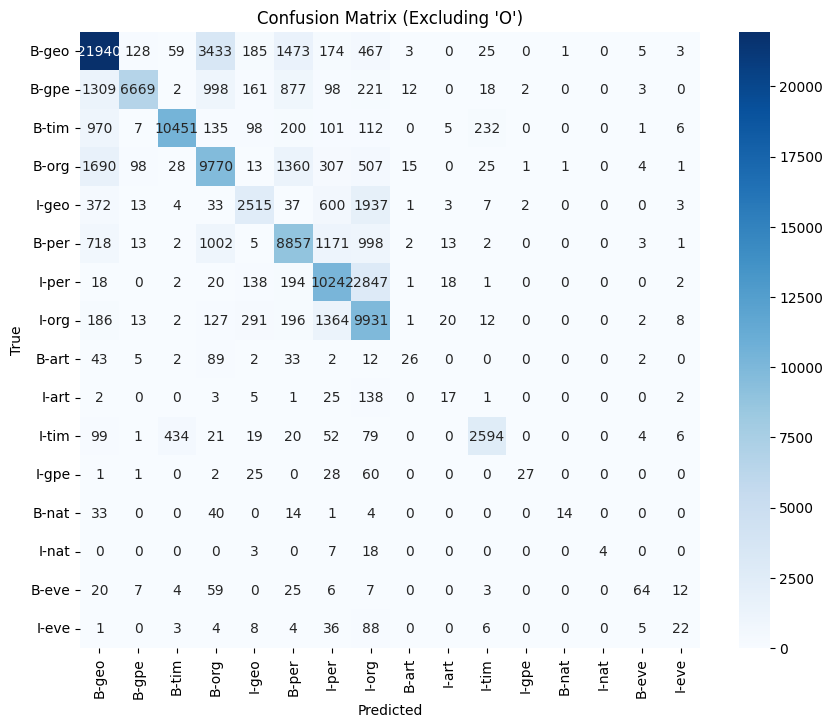

In [4]:
y_pred = crf.predict(X_test)
labels = list(crf.classes_)
labels.remove('O')

# Accuracy excluding 'O'
flat_y_test = [item for sublist in y_test for item in sublist]
flat_y_pred = [item for sublist in y_pred for item in sublist]

mask = [y != 'O' for y in flat_y_test]
filtered_y_test = [flat_y_test[i] for i in range(len(flat_y_test)) if mask[i]]
filtered_y_pred = [flat_y_pred[i] for i in range(len(flat_y_pred)) if mask[i]]

acc_no_O = accuracy_score(filtered_y_test, filtered_y_pred)
print(f"Accuracy (excluding 'O'): {acc_no_O:.4f}")

# F1-score
f1 = metrics.flat_f1_score(y_test, y_pred, average='weighted', labels=labels)
print(f"F1 Score (weighted, excluding 'O'): {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(filtered_y_test, filtered_y_pred, labels=labels)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.title("Confusion Matrix (Excluding 'O')")
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

## Tiny Test Evaluation
Predicting on `tiny_test.csv`.

In [5]:
# Tiny test prediction
with open('../nlp_d2_data/tiny_test.csv', 'r') as f:
    lines = f.readlines()
    for line in lines:
        if line.startswith('#') or len(line.strip()) == 0:
            continue
        words = line.strip().split()
        # Mock sentence format
        sent = [(w, 'O') for w in words]
        features = sent2features(sent)
        preds = crf.predict([features])[0]
        
        output = " ".join([f"{w}/{t}" for w, t in zip(words, preds)])
        print(output)

sentence_id,words,tags/O
0,The,O/O
0,programmers,O/O
0,from,O/O
0,Barcelona,B-geo/O
0,might,O/O
0,write,O/O
0,a,O/O
0,sentence,O/O
0,without,O/O
0,a,O/O
0,spell,O/O
0,checker,O/O
0,.,O/B-org
1,The,O/O
1,programmers,O/O
1,from,O/O
1,Barchelona,B-geo/O
1,cannot,O/O
1,write,O/O
1,a,O/O
1,sentence,O/O
1,without,O/O
1,a,O/O
1,spell,O/O
1,checker,O/O
1,.,O/B-org
2,Jack,B-per/O
2,London,I-per/O
2,went,O/O
2,to,O/O
2,Parris,B-geo/O
2,.,O/B-org
3,Jack,B-per/O
3,London,I-per/O
3,went,O/O
3,to,O/O
3,Paris,B-geo/O
3,.,O/B-org
4,Bill,B-per/O
4,gates,I-per/O
4,and,O/O
4,Steve,B-per/O
4,jobs,I-per/O
4,never,O/O
4,thought,O/O
4,Microsoft,B-org/O
4,would,O/O
4,become,O/O
4,such,O/O
4,a,O/O
4,big,O/O
4,company,O/O
4,.,O/B-org
5,Bill,B-per/O
5,Gates,I-per/O
5,and,O/O
5,Steve,B-per/O
5,Jobs,I-per/O
5,never,O/O
5,thought,O/O
5,Microsoft,B-org/O
5,would,O/O
5,become,O/O
5,such,O/O
5,a,O/O
5,big,O/O
5,company,O/O
5,.,O/B-org
6,The,O/O
6,president,O/O
6,of,O/O
6,U.S.A,B-geo/O
6,thought,O/O
6,they,O/O
6,could,